<a href="https://colab.research.google.com/github/kfafa2018-ux/NLP-LCCC/blob/main/NLP_Term_Frequency_Week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TF-IDF Calculation

First, let's define the sentences that will form our corpus.

In [1]:
documents = [
    "This novel is from a long time ago.",
    "The novel is Victorian.",
    "You should read more novels.",
    "To read novels is to improve your vocabulary."
]

for i, doc in enumerate(documents):
    print(f"Document {i+1}: {doc}")

Document 1: This novel is from a long time ago.
Document 2: The novel is Victorian.
Document 3: You should read more novels.
Document 4: To read novels is to improve your vocabulary.


### Tokenization
Next, we need to tokenize the documents, converting each sentence into a list of words and normalizing them (e.g., lowercasing).

re.findall(pattern, string): This function finds all non-overlapping matches of pattern in the string and returns them as a list of strings.
r'\b\w+\b': This is the regular expression pattern:
r: Denotes a 'raw string', which treats backslashes as literal characters, preventing them from being interpreted as escape sequences by Python itself. This is common practice for regex patterns.
\b: Is a word boundary. It matches the position between a word character and a non-word character (or the start/end of the string).
\w: Matches any word character (alphanumeric characters plus underscore: [a-zA-Z0-9_]).
+: Matches one or more occurrences of the preceding character or group.

In [2]:
import re
import nltk
from nltk.corpus import stopwords
# We see that nltk was imported so that the notebook would recognize stopwords
# in the sentences (docs)

nltk.download('punkt', quiet=True)
#In NLTK, punkt is an unsupervised machine learning model used primarily for
# sentence boundary detection (splitting text into sentences) rather than
# word-level tokenization. However, it heavily relies on internal word tables
# (specifically abbreviations and sentence starters) to make its decisions
nltk.download('stopwords', quiet=True)

def tokenize(document):
    # Lowercase and remove punctuation, then split into words
    words = re.findall(r'\b\w+\b', document.lower())
    # Optionally remove stopwords (can be toggled based on use case)
    # stop_words = set(stopwords.words('english'))
    # words = [word for word in words if word not in stop_words]
    return words

tokenized_documents = [tokenize(doc) for doc in documents]

for i, tokens in enumerate(tokenized_documents):
    print(f"Document {i+1} tokens: {tokens}")

Document 1 tokens: ['this', 'novel', 'is', 'from', 'a', 'long', 'time', 'ago']
Document 2 tokens: ['the', 'novel', 'is', 'victorian']
Document 3 tokens: ['you', 'should', 'read', 'more', 'novels']
Document 4 tokens: ['to', 'read', 'novels', 'is', 'to', 'improve', 'your', 'vocabulary']


### Handling Stop Words
Stop words are common words (like 'the', 'is', 'a') that often carry little meaning in the context of text analysis and can skew relevance scores. We can remove them during tokenization.

In [6]:
import re
#re stands for the regular expressions module in Python
#It has tools for pattern matching and string manipulation
import nltk
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

def tokenize_with_stopwords(document):
    # Lowercase and remove punctuation, then split into words
    words = re.findall(r'\b\w+\b', document.lower())
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]
    return filtered_words

# Re-tokenize documents with stop word removal
tokenized_documents_filtered = [tokenize_with_stopwords(doc) for doc in documents]

print("Tokenized Documents (with stop words removed):")
for i, tokens in enumerate(tokenized_documents_filtered):
    print(f"Document {i+1} tokens: {tokens}")

Tokenized Documents (with stop words removed):
Document 1 tokens: ['novel', 'long', 'time', 'ago']
Document 2 tokens: ['novel', 'victorian']
Document 3 tokens: ['read', 'novels']
Document 4 tokens: ['read', 'novels', 'improve', 'vocabulary']


### Analyzing Rare and Frequent Words
After removing stop words, we can analyze the frequency of the remaining terms across the entire corpus to identify words that are too rare (and thus might be noise or misspellings) or still too frequent (and might not be very discriminative even after stop word removal).

Let's calculate the overall term frequencies.

Counter What it does:

It takes an iterable (like a list of words) and returns a dictionary-like object where elements are stored as dictionary keys and their counts are stored as dictionary values.
 Here, all_terms was a list of all words from all documents after tokenization and stop word removal. Counter(all_terms) efficiently calculated how many times each unique word appeared in the entire corpus, giving us {'novel': 2, 'read': 2, 'novels': 2, ...}.

In [7]:
from collections import Counter
import itertools
#itertools a module that works with iterators. Designed for creating
#efficient looping constructs.

# Flatten the list of lists of tokens into a single list of all terms in the corpus
all_terms = list(itertools.chain.from_iterable(tokenized_documents_filtered))
#tokenized_documents-filtered list of lists
 #(e.g., [['novel', 'long'], ['novel', 'victorian']]). We needed to flatten
 #this into a single list of all terms (['novel', 'long', 'novel', 'victorian'])
 # to count their overall frequency in the corpus.

 #So, itertools.chain.from_iterable helped us efficiently combine all the
 # individual word lists from our documents into one long list, which Counter
 # then used to tally word occurrences. Both are excellent tools for text
 #processing in Python!

# Calculate the frequency of each term in the entire corpus
corpus_term_frequency = Counter(all_terms)

print("Overall Corpus Term Frequencies:")
# Display top 10 and bottom 10 terms for an overview
print("Most Common Terms:", corpus_term_frequency.most_common(10))
print("Least Common Terms (excluding terms with count 1, if any):")
least_common = sorted([(term, count) for term, count in corpus_term_frequency.items() if count > 1], key=lambda item: item[1])
if not least_common: # If all terms only appear once
    print("All remaining terms appear only once.")
else:
    print(least_common[:10]) # Display up to 10 least common

Overall Corpus Term Frequencies:
Most Common Terms: [('novel', 2), ('read', 2), ('novels', 2), ('long', 1), ('time', 1), ('ago', 1), ('victorian', 1), ('improve', 1), ('vocabulary', 1)]
Least Common Terms (excluding terms with count 1, if any):
[('novel', 2), ('read', 2), ('novels', 2)]


### Elbow Method for Term Filtering
The 'elbow method' often refers to a heuristic used in clustering to find the optimal number of clusters. In the context of term filtering based on frequency, it can be applied by visualizing the sorted term frequencies and looking for a point where the 'gain' in keeping more terms significantly diminishes. This helps in setting thresholds for rare or overly frequent words.

Let's plot the term frequencies to identify potential cut-off points.

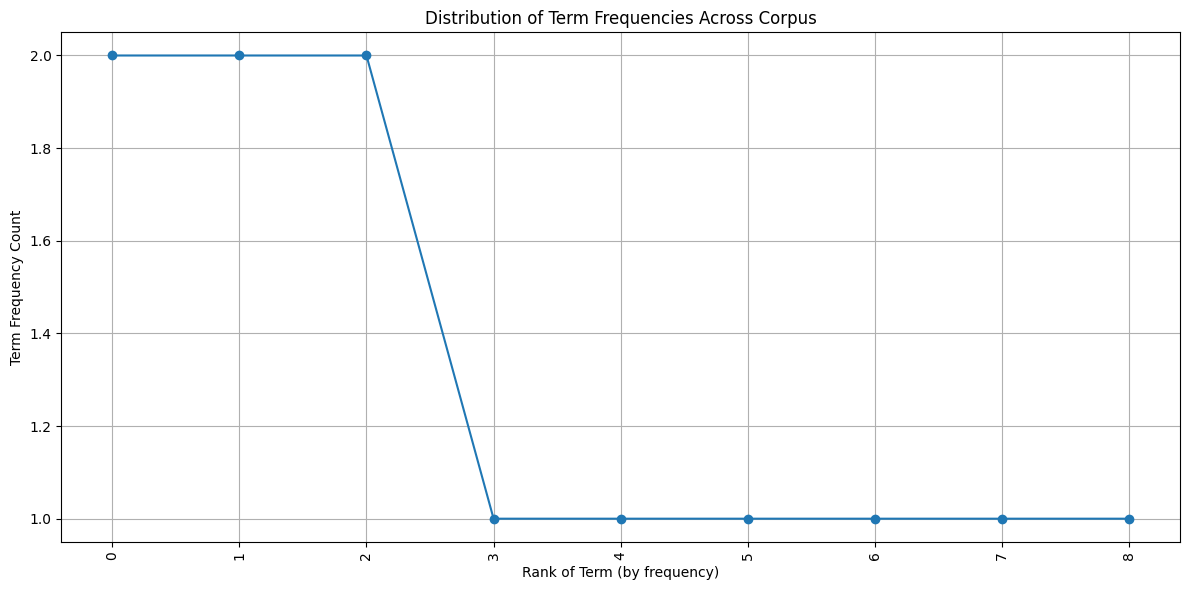

Based on the plot, we can visually identify thresholds for removing very rare or very common words.
For instance, we might decide to remove terms that appear only once, or terms that appear in almost every document (after stop word removal).


In [8]:
import matplotlib.pyplot as plt

# Sort terms by frequency for plotting
sorted_term_frequencies = corpus_term_frequency.most_common()
terms = [item[0] for item in sorted_term_frequencies]
counts = [item[1] for item in sorted_term_frequencies]

plt.figure(figsize=(12, 6))
plt.plot(range(len(counts)), counts, marker='o', linestyle='-')
plt.title('Distribution of Term Frequencies Across Corpus')
plt.xlabel('Rank of Term (by frequency)')
plt.ylabel('Term Frequency Count')
plt.xticks(range(0, len(terms), max(1, len(terms)//10)), rotation=90) # Show some term labels
plt.grid(True)
plt.tight_layout()
plt.show()

print("Based on the plot, we can visually identify thresholds for removing very rare or very common words.")
print("For instance, we might decide to remove terms that appear only once, or terms that appear in almost every document (after stop word removal).")

---

Now that we've refined our tokenization and considered term filtering, we would proceed with recalculating TF, IDF, and TF-IDF using `tokenized_documents_filtered`.

### Term Frequency (TF)
Now we calculate the Term Frequency for each term in each document. A common approach is to use the raw count or a normalized count (term occurrences / total terms in document).

In [9]:
from collections import Counter

def calculate_tf(tokenized_document):
    term_counts = Counter(tokenized_document)
    total_terms = len(tokenized_document)
    # Avoid division by zero for empty documents
    tf = {term: count / total_terms for term, count in term_counts.items()} if total_terms > 0 else {}
    return tf

tf_scores = [calculate_tf(doc_tokens) for doc_tokens in tokenized_documents_filtered] # Changed to filtered documents

print("Term Frequencies (TF):")
for i, scores in enumerate(tf_scores):
    print(f"Document {i+1}: {scores}")

Term Frequencies (TF):
Document 1: {'novel': 0.25, 'long': 0.25, 'time': 0.25, 'ago': 0.25}
Document 2: {'novel': 0.5, 'victorian': 0.5}
Document 3: {'read': 0.5, 'novels': 0.5}
Document 4: {'read': 0.25, 'novels': 0.25, 'improve': 0.25, 'vocabulary': 0.25}


### Inverse Document Frequency (IDF)
Next, we calculate the Inverse Document Frequency. This measures how common or rare a word is across all documents. Words that appear in many documents will have a lower IDF, while rare words will have a higher IDF.

In [10]:
import math

def calculate_idf(tokenized_documents):
    N = len(tokenized_documents) # Total number of documents
    idf = {}
    # Count document frequency for each term
    document_frequency = Counter()
    for doc_tokens in tokenized_documents:
        unique_terms_in_doc = set(doc_tokens)
        for term in unique_terms_in_doc:
            document_frequency[term] += 1

    # Calculate IDF for each term
    for term, count in document_frequency.items():
        # Add 1 to denominator to avoid division by zero for terms not in any document if N=0
        idf[term] = math.log(N / (count)) # Standard IDF formula
    return idf

idf_scores = calculate_idf(tokenized_documents_filtered) # Changed to filtered documents

print("Inverse Document Frequencies (IDF):")
print(idf_scores)

Inverse Document Frequencies (IDF):
{'ago': 1.3862943611198906, 'time': 1.3862943611198906, 'novel': 0.6931471805599453, 'long': 1.3862943611198906, 'victorian': 1.3862943611198906, 'novels': 0.6931471805599453, 'read': 0.6931471805599453, 'vocabulary': 1.3862943611198906, 'improve': 1.3862943611198906}


### TF-IDF Table
Finally, we combine the TF and IDF scores to get the TF-IDF score for each term in each document. A higher TF-IDF score indicates that a term is more important in a particular document relative to the entire corpus.

In [11]:
import pandas as pd

def calculate_tfidf(tf_scores, idf_scores):
    tfidf_matrix = []
    all_terms = sorted(list(idf_scores.keys())) # Get all unique terms for consistent columns

    for doc_tf in tf_scores:
        doc_tfidf = {term: 0.0 for term in all_terms} # Initialize with 0.0
        for term, tf in doc_tf.items():
            doc_tfidf[term] = tf * idf_scores.get(term, 0.0) # Use .get for terms not in IDF (shouldn't happen here)
        tfidf_matrix.append(doc_tfidf)

    # Convert to DataFrame for better visualization
    tfidf_df = pd.DataFrame(tfidf_matrix, index=[f'Document {i+1}' for i in range(len(tf_scores))])
    return tfidf_df

tfidf_table = calculate_tfidf(tf_scores, idf_scores)

print("TF-IDF Table (with stop words removed):")
display(tfidf_table)

TF-IDF Table (with stop words removed):


,ago,improve,long,novel,novels,read,time,victorian,vocabulary
Document 1,0.346574,0.000000,0.346574,0.173287,0.000000,0.000000,0.346574,0.000000,0.000000
Document 2,0.000000,0.000000,0.000000,0.346574,0.000000,0.000000,0.000000,0.693147,0.000000
Document 3,0.000000,0.000000,0.000000,0.000000,0.346574,0.346574,0.000000,0.000000,0.000000
Document 4,0.000000,0.346574,0.000000,0.000000,0.173287,0.173287,0.000000,0.000000,0.346574
